
Loaded files:
S-M-06-int.csv
S-M-07-int.csv
S-M-11-int.csv
S-M-12-int.csv
S-M-14-int.csv
S-M-27-int.csv

FITTING PARAMETERS ONCE USING FIRST 12 POINTS
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3646e+02                                    7.22e+01    
       1              2         1.0549e+02      3.10e+01       1.47e-02       1.61e+01    
       2              3         9.5043e+01      1.04e+01       8.86e-02       4.21e+00    
       3              4         9.2238e+01      2.81e+00       4.19e-02       1.01e+00    
       4              5         9.1339e+01      8.98e-01       1.86e-02       3.26e-01    
       5              6         9.1204e+01      1.35e-01       5.05e-03       6.11e-02    
       6              7         9.1181e+01      2.30e-02       1.10e-03       5.26e-03    
       7              8         9.1181e+01      4.18e-06       2.76e-05       8.91e-05    
       8              9      

 forecast_index  forecast_day forecast_date  H_obs  H_forecast  H_error  B_obs  B_forecast  B_error
             12         107.0    2024-07-25    1.0      1.1493   0.1493 7.9800      6.5474  -1.4326
             13         181.0    2024-10-07    5.0      3.7879  -1.2121 9.9750      6.1099  -3.8651
             14         203.0    2024-10-29    3.0      5.8959   2.8959 9.9750      9.0423  -0.9327
             15         210.0    2024-11-05    3.0      3.3358   0.3358 9.9250      9.6219  -0.3031
             16         219.0    2024-11-14    4.0      3.4256  -0.5744 6.9125      9.4823   2.5698
             17         244.0    2024-12-09    6.0      4.7570  -1.2430 4.9250      6.5347   1.6097
             18         258.0    2024-12-23    5.0      6.2838   1.2838 6.9125      4.9665  -1.9460

Forecast RMSE:
H RMSE = 1.3894
B RMSE = 2.1022


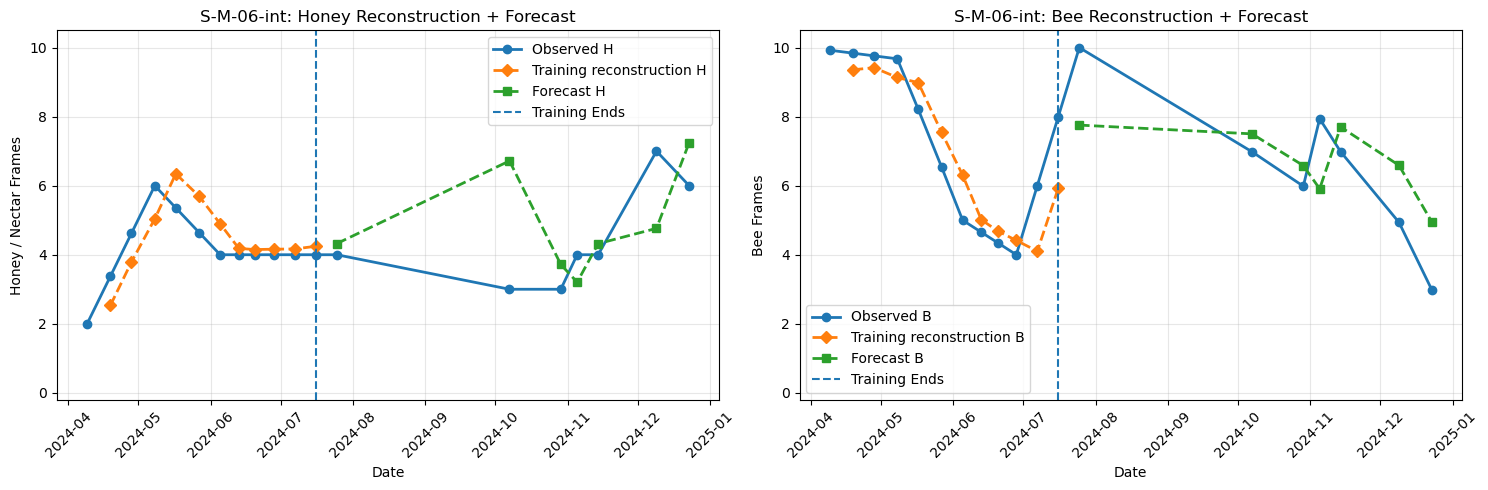

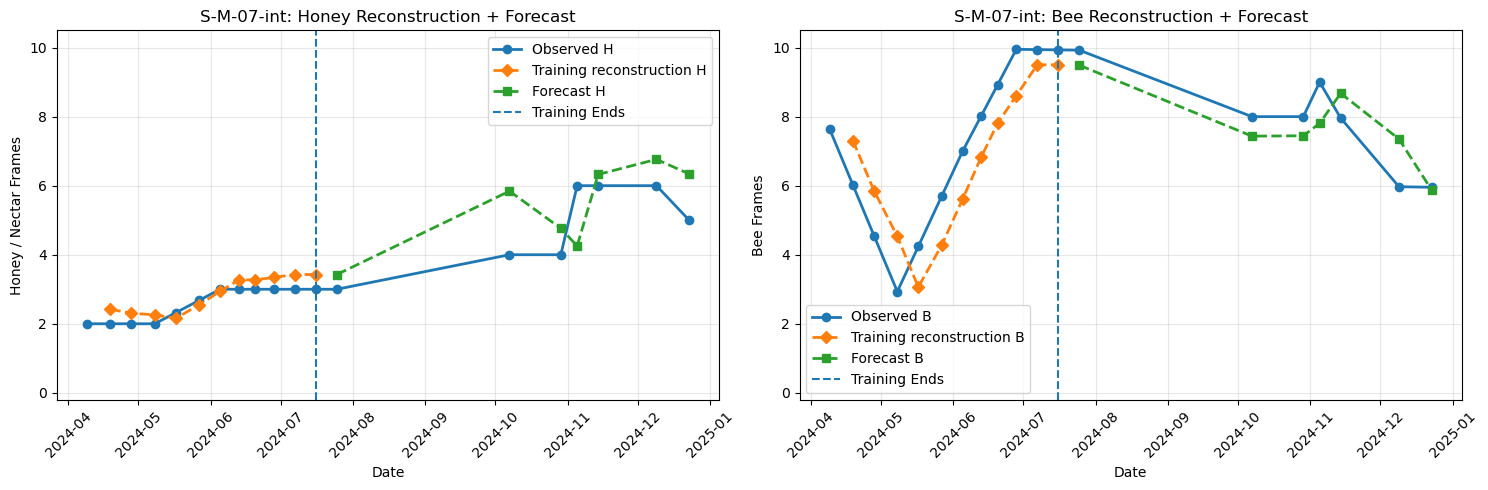

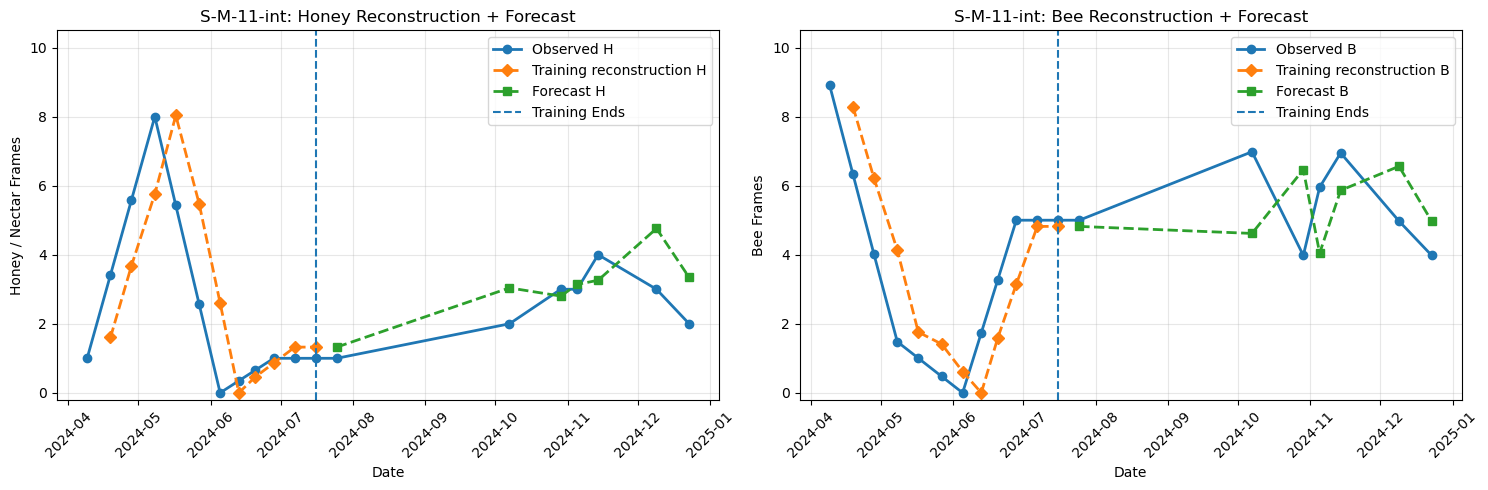

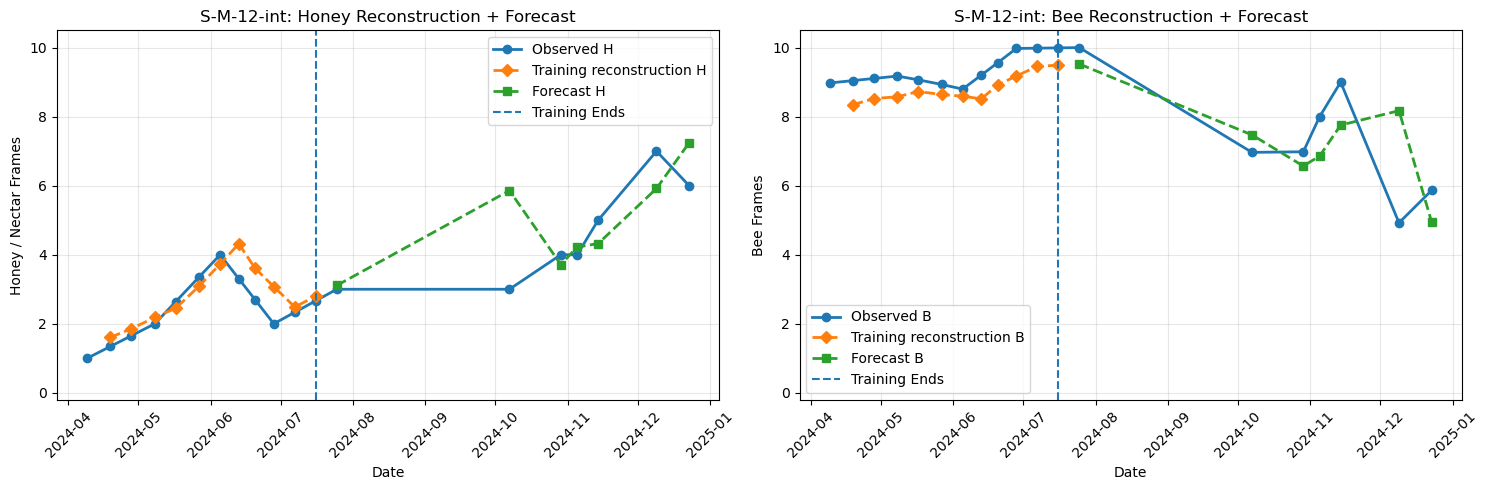

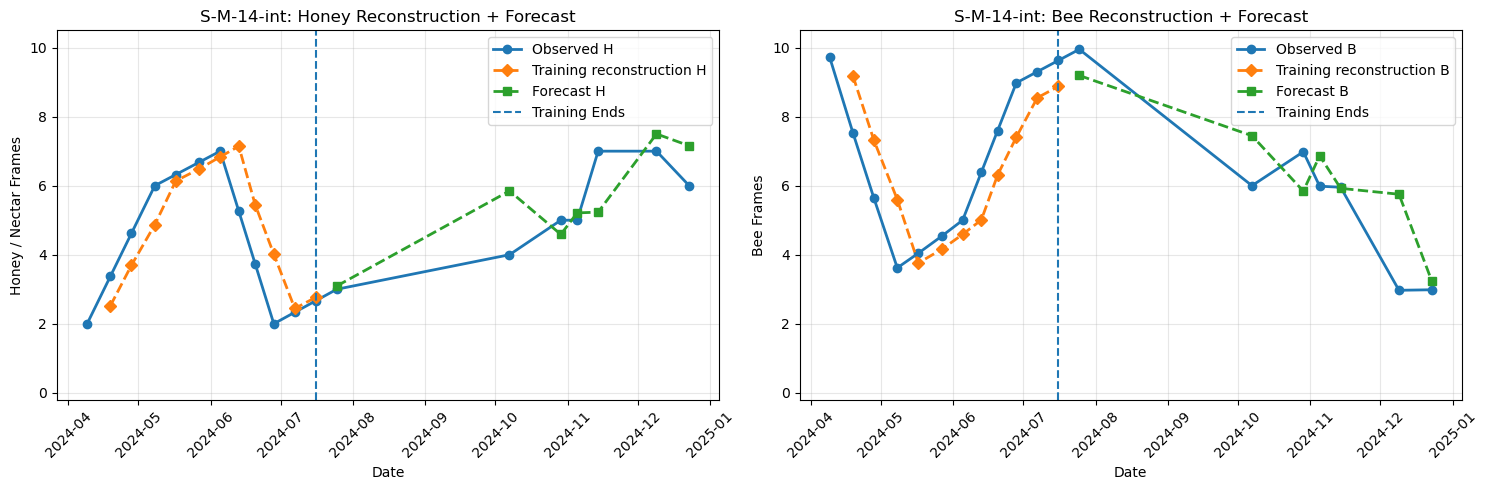

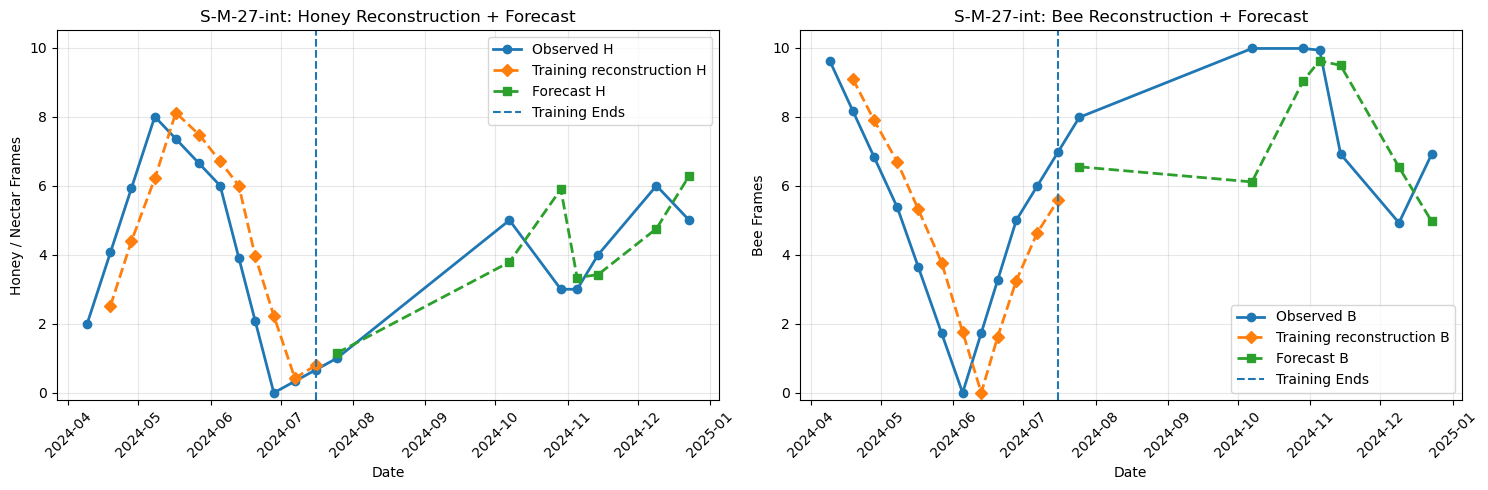

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\S-M-train-int"

TRAIN_POINTS = 12
K = 1

# ============================================================
# LOAD ALL HIVE FILES
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": np.array(data["Nectar"], dtype=float),
            "B": np.array(data["Frame Healthy Bees"], dtype=float),
        },
    }

    all_hives.append(hive)

# ============================================================
# QUEEN FUNCTION
# ============================================================

def queen_absence_window_func(inspection_times, queen_values, d1=5, d2=2):
    inspection_times = np.asarray(inspection_times, dtype=float)
    queen_values = np.asarray(queen_values, dtype=float)

    windows = []

    for t, q in zip(inspection_times, queen_values):
        if q == 0:
            windows.append((t - d1, t + d2))

    def Q_func(t):
        for start, end in windows:
            if start <= t <= end:
                return 0.0
        return 1.0

    return Q_func

# ============================================================
# ODE MODEL
# ============================================================

def ode_rhs(t, y, p, Q_func):
    H = float(y[0])
    B = float(y[1])

    Q = float(Q_func(t))

    S_collect = 1.0 / (1.0 + np.exp(K * (H - 10.0)))
    S_consume = 1.0 / (1.0 + np.exp(-K * (H - 0.01)))

    dH = (
        B * p["c1"] * S_collect
        - B * p["c2"] * S_consume
    )

    dB = (
        p["c3"] * Q * S_collect * S_consume
        - B * (
            2*p["c7"]
            + (p["c7"] - 2*p["c7"])
            / (1.0 + np.exp(-K * (H - 0.01)))
        )
    )

    return [dH, dB]

# ============================================================
# SOLVER
# ============================================================

def simulate_model(t_points, y0, params, Q_func):
    t_points = np.asarray(t_points, dtype=float)

    if len(t_points) < 2:
        return np.array([[y0[0]], [y0[1]]])

    sol = solve_ivp(
        fun=lambda t, y: ode_rhs(t, y, params, Q_func),
        t_span=(t_points[0], t_points[-1]),
        y0=np.asarray(y0, dtype=float),
        t_eval=t_points,
        method="RK45",
        rtol=1e-4,
        atol=1e-6,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return np.maximum(sol.y, 0.0)

# ============================================================
# PARAMETERS
# ============================================================

FIT_KEYS = ["c1", "c3", "c7"]

fixed_params = {
    "c2": 0.0122,
}

lower_bounds = {
    "c1": 0.0123,
    "c3": 0.0001,
    "c7": 0.01,
}

upper_bounds = {
    "c1": 0.0556,
    "c3": 0.571,
    "c7": 0.08,
}

init_guess = {
    "c1": 0.03,
    "c3": 0.20,
    "c7": 0.04,
}

weights = {
    "H": 1.0,
    "B": 1.0,
}

# ============================================================
# PACK / UNPACK
# ============================================================

def pack_theta(p):
    return np.array([p[k] for k in FIT_KEYS], dtype=float)

def unpack_theta(theta):
    p = fixed_params.copy()
    for i, k in enumerate(FIT_KEYS):
        p[k] = theta[i]
    return p

# ============================================================
# GLOBAL RESIDUALS
# Fit parameters using first TRAIN_POINTS
# ============================================================

def global_residuals(theta):
    try:
        params = unpack_theta(theta)
        residuals = []

        for hive in all_hives:
            t_all = hive["t"]
            obsH = hive["obs"]["H"]
            obsB = hive["obs"]["B"]

            if len(t_all) < TRAIN_POINTS:
                continue

            Q_func = queen_absence_window_func(
                hive["data"]["Day"],
                hive["data"]["Queen"],
            )

            # reconstruct training points:
            # 0 -> 1, 1 -> 2, ..., TRAIN_POINTS-2 -> TRAIN_POINTS-1
            for recon_idx in range(1, TRAIN_POINTS):

                ic_idx = recon_idx - 1

                y0 = [
                    obsH[ic_idx],
                    obsB[ic_idx],
                ]

                t_recon = np.array([
                    t_all[ic_idx],
                    t_all[recon_idx],
                ])

                Y = simulate_model(
                    t_recon,
                    y0,
                    params,
                    Q_func,
                )

                H_pred = Y[0][-1]
                B_pred = Y[1][-1]

                residuals.append((H_pred - obsH[recon_idx]) / weights["H"])
                residuals.append((B_pred - obsB[recon_idx]) / weights["B"])

        if len(residuals) == 0:
            return 1e6 * np.ones(100)

        return np.array(residuals)

    except Exception as e:
        print("Residual error:", e)
        return 1e6 * np.ones(100)

# ============================================================
# FIT PARAMETERS ONCE
# ============================================================

print("\n" + "=" * 80)
print(f"FITTING PARAMETERS ONCE USING FIRST {TRAIN_POINTS} POINTS")
print("=" * 80)

x0 = pack_theta(init_guess)

lb = np.array([lower_bounds[k] for k in FIT_KEYS], dtype=float)
ub = np.array([upper_bounds[k] for k in FIT_KEYS], dtype=float)

fit_result = least_squares(
    fun=global_residuals,
    x0=x0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=5000,
    verbose=2,
)

params_hat = unpack_theta(fit_result.x)

print("\nEstimated parameters:")
for k in FIT_KEYS:
    print(f"{k} = {params_hat[k]:.8f}")
print(f"c2 = {params_hat['c2']:.8f}")
print(f"Training cost = {fit_result.cost:.6f}")

# ============================================================
# TRAINING RECONSTRUCTION
# Use previous observed point as IC to reconstruct next training point
# No reconstruction for index 0
# ============================================================

training_recon_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]
    obsH = hive["obs"]["H"]
    obsB = hive["obs"]["B"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    records = []

    max_train_idx = min(TRAIN_POINTS, len(t_all))

    for recon_idx in range(1, max_train_idx):

        ic_idx = recon_idx - 1

        y0 = [
            obsH[ic_idx],
            obsB[ic_idx],
        ]

        t_recon = np.array([
            t_all[ic_idx],
            t_all[recon_idx],
        ])

        Y = simulate_model(
            t_recon,
            y0,
            params_hat,
            Q_func,
        )

        H_recon = Y[0][-1]
        B_recon = Y[1][-1]

        records.append({
            "recon_index": recon_idx,
            "recon_day": t_all[recon_idx],
            "recon_date": dates[recon_idx],

            "H_obs": obsH[recon_idx],
            "H_recon": H_recon,
            "H_recon_error": H_recon - obsH[recon_idx],

            "B_obs": obsB[recon_idx],
            "B_recon": B_recon,
            "B_recon_error": B_recon - obsB[recon_idx],
        })

    training_recon_records[name] = pd.DataFrame(records)

# ============================================================
# ONE-STEP-AHEAD FORECASTING AFTER TRAINING
# Use previous observed point as IC
# First forecast target = TRAIN_POINTS
# IC = TRAIN_POINTS - 1
# ============================================================

forecast_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]
    obsH = hive["obs"]["H"]
    obsB = hive["obs"]["B"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    records = []

    for forecast_idx in range(TRAIN_POINTS, len(t_all)):

        ic_idx = forecast_idx - 1

        y0 = [
            obsH[ic_idx],
            obsB[ic_idx],
        ]

        t_forecast = np.array([
            t_all[ic_idx],
            t_all[forecast_idx],
        ])

        Y = simulate_model(
            t_forecast,
            y0,
            params_hat,
            Q_func,
        )

        H_forecast = Y[0][-1]
        B_forecast = Y[1][-1]

        records.append({
            "forecast_index": forecast_idx,
            "forecast_day": t_all[forecast_idx],
            "forecast_date": dates[forecast_idx],

            "H_obs": obsH[forecast_idx],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[forecast_idx],

            "B_obs": obsB[forecast_idx],
            "B_forecast": B_forecast,
            "B_error": B_forecast - obsB[forecast_idx],
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT RESULTS
# ============================================================

for hive in all_hives:
    name = hive["name"]

    df_recon = training_recon_records[name]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"RESULTS: {name}")
    print("=" * 80)

    if not df_recon.empty:
        print("\nTraining reconstruction:")
        print(df_recon.round(4).to_string(index=False))

        H_recon_rmse = np.sqrt(np.mean(df_recon["H_recon_error"] ** 2))
        B_recon_rmse = np.sqrt(np.mean(df_recon["B_recon_error"] ** 2))

        print("\nTraining reconstruction RMSE:")
        print(f"H RMSE = {H_recon_rmse:.4f}")
        print(f"B RMSE = {B_recon_rmse:.4f}")

    if not df_forecast.empty:
        print("\nForecasting:")
        print(df_forecast.round(4).to_string(index=False))

        H_forecast_rmse = np.sqrt(np.mean(df_forecast["H_error"] ** 2))
        B_forecast_rmse = np.sqrt(np.mean(df_forecast["B_error"] ** 2))

        print("\nForecast RMSE:")
        print(f"H RMSE = {H_forecast_rmse:.4f}")
        print(f"B RMSE = {B_forecast_rmse:.4f}")

# ============================================================
# PLOT TRAINING RECONSTRUCTION + FORECAST
# ============================================================

for hive in all_hives:
    name = hive["name"]

    dates = hive["dates"]
    obsH = hive["obs"]["H"]
    obsB = hive["obs"]["B"]

    df_recon = training_recon_records[name]
    df_forecast = forecast_records[name]

    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # --------------------------------------------------------
    # Honey / Nectar plot
    # --------------------------------------------------------

    axs[0].plot(
        dates,
        obsH,
        "o-",
        label="Observed H",
        linewidth=2,
    )

    if not df_recon.empty:
        axs[0].plot(
            df_recon["recon_date"],
            df_recon["H_recon"],
            "D--",
            label="Training reconstruction H",
            linewidth=2,
        )

    if not df_forecast.empty:
        axs[0].plot(
            df_forecast["forecast_date"],
            df_forecast["H_forecast"],
            "s--",
            label="Forecast H",
            linewidth=2,
        )

    axs[0].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[0].set_title(f"{name}: Honey Reconstruction + Forecast")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Honey / Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    # --------------------------------------------------------
    # Bee plot
    # --------------------------------------------------------

    axs[1].plot(
        dates,
        obsB,
        "o-",
        label="Observed B",
        linewidth=2,
    )

    if not df_recon.empty:
        axs[1].plot(
            df_recon["recon_date"],
            df_recon["B_recon"],
            "D--",
            label="Training reconstruction B",
            linewidth=2,
        )

    if not df_forecast.empty:
        axs[1].plot(
            df_forecast["forecast_date"],
            df_forecast["B_forecast"],
            "s--",
            label="Forecast B",
            linewidth=2,
        )

    axs[1].axvline(
        x=dates[TRAIN_POINTS - 1],
        linestyle="--",
        linewidth=1.5,
        label="Training Ends",
    )

    axs[1].set_title(f"{name}: Bee Reconstruction + Forecast")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Bee Frames")
    axs[1].set_ylim(-0.2, 10.5)
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


Loaded files:
24SRA.csv
24SRB.csv
24SRG.csv
24SRK.csv
24SRL.csv

ONE-DAY-AHEAD FORECAST RESULTS: 24SRA
 from_index  forecast_index  from_day  forecast_day forecast_date  H_obs  H_forecast  H_error  B_obs  B_forecast  B_error
          0               1       0.0          21.0    2024-07-29    2.0      2.8853   0.8853 9.0000      9.1242   0.1242
          1               2      21.0          43.0    2024-08-20    2.0      2.8383   0.8383 8.0000      8.2844   0.2844
          2               3      43.0          65.0    2024-09-11    3.0      2.7511  -0.2489 8.0000      7.4819  -0.5181
          3               4      65.0          84.0    2024-09-30    4.0      3.6516  -0.3484 5.9114      7.5460   1.6346
          4               5      84.0         113.0    2024-10-29    7.0      4.7480  -2.2520 9.8361      5.7768  -4.0593
          5               6     113.0         135.0    2024-11-20    8.0      7.9112  -0.0888 5.8922      8.9554   3.0632
          6               7     135.0     

C:\Users\mhoss\AppData\Local\Temp\ipykernel_8244\2702273594.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_8244\2702273594.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_8244\2702273594.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])
C:\Users\mhoss\AppData\Local\Temp\ipykernel_8244\2702273594.py:43: UserWarning: Could not infer format, so ea

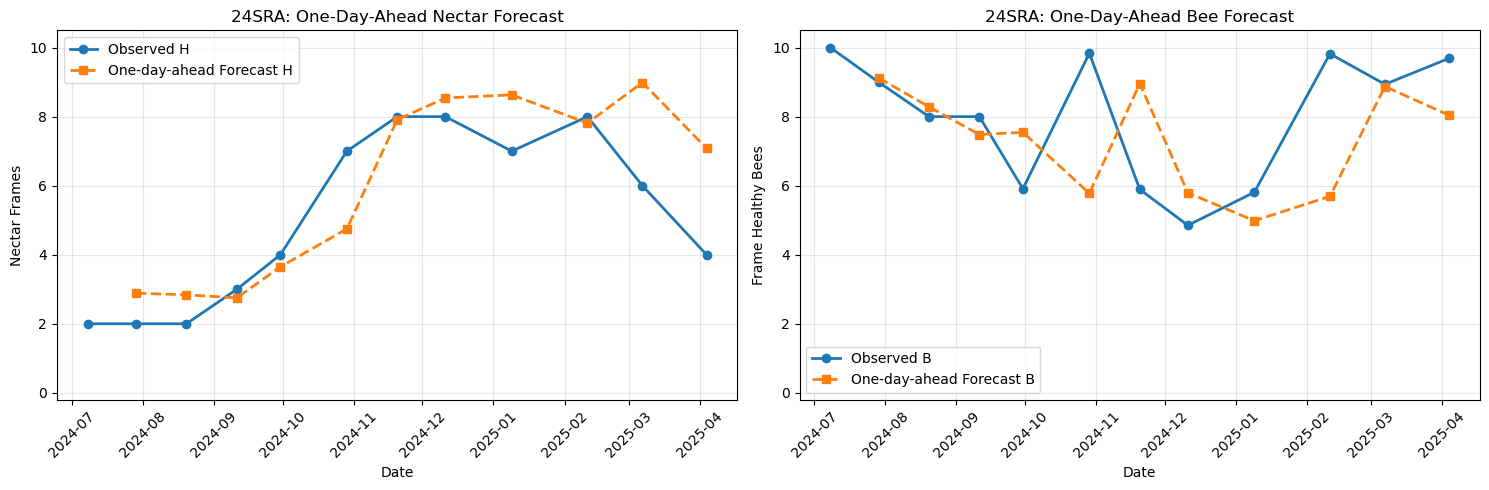

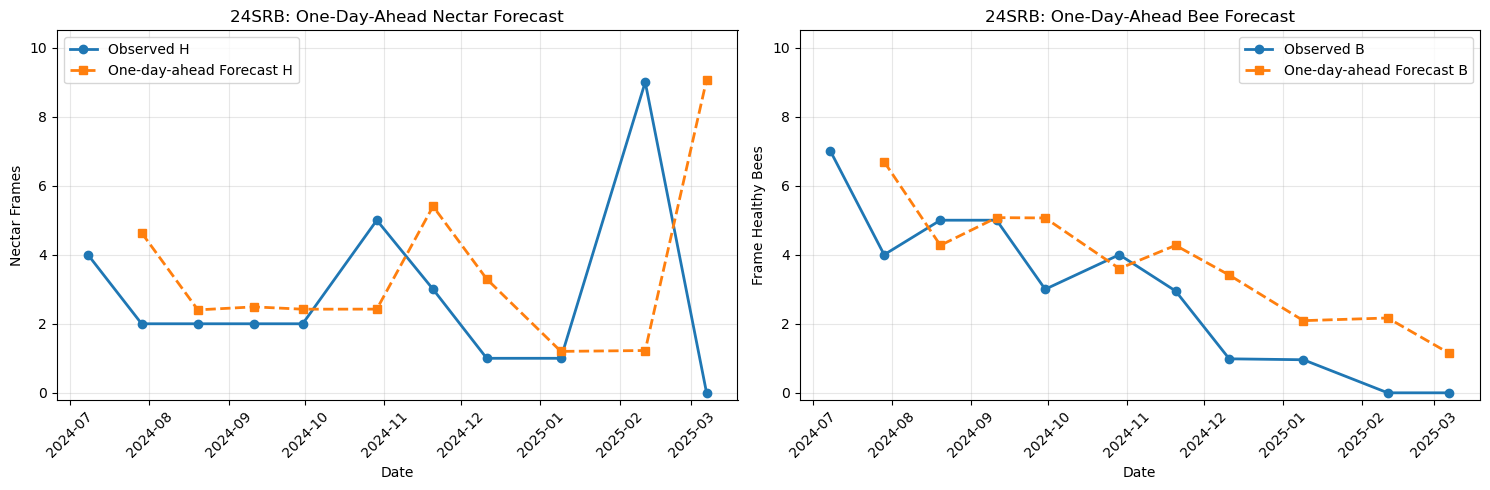

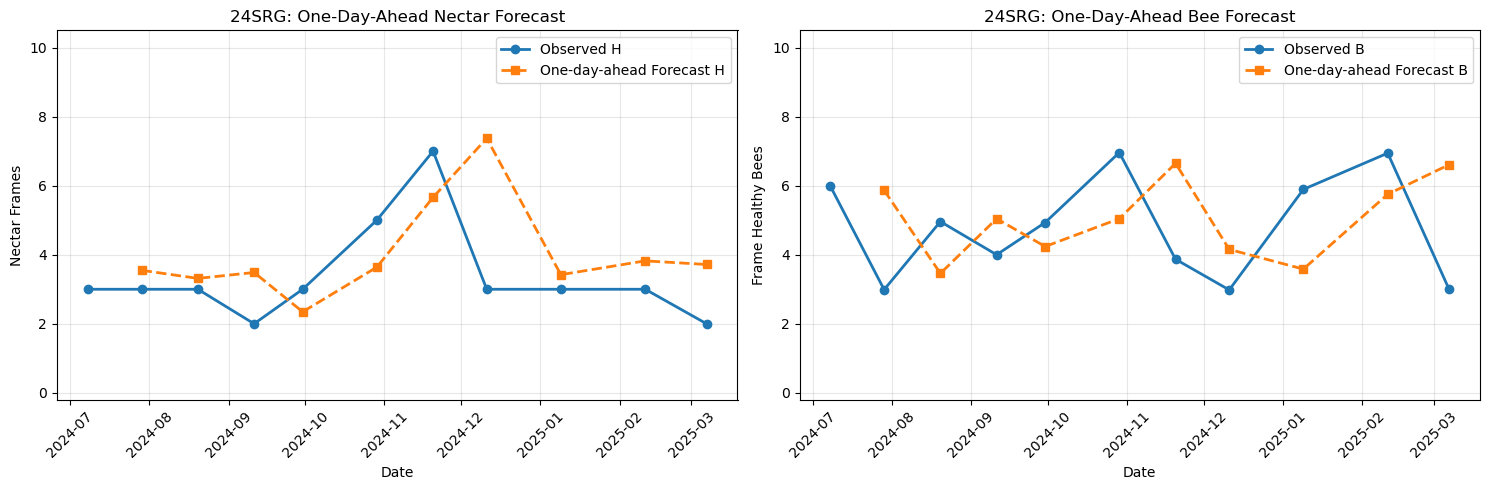

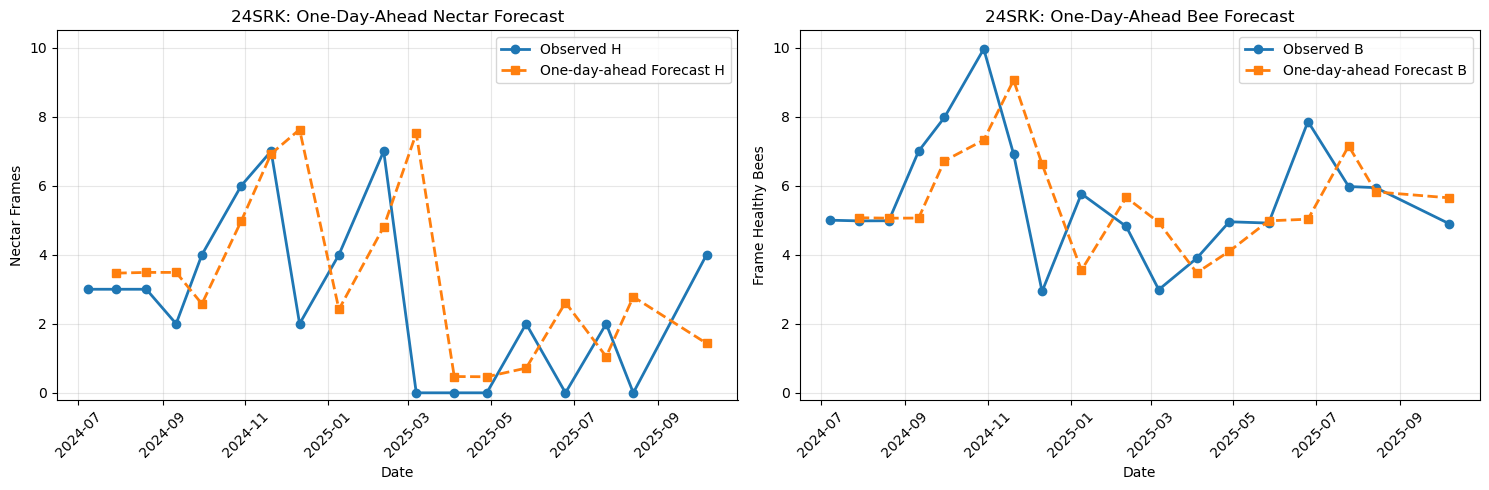

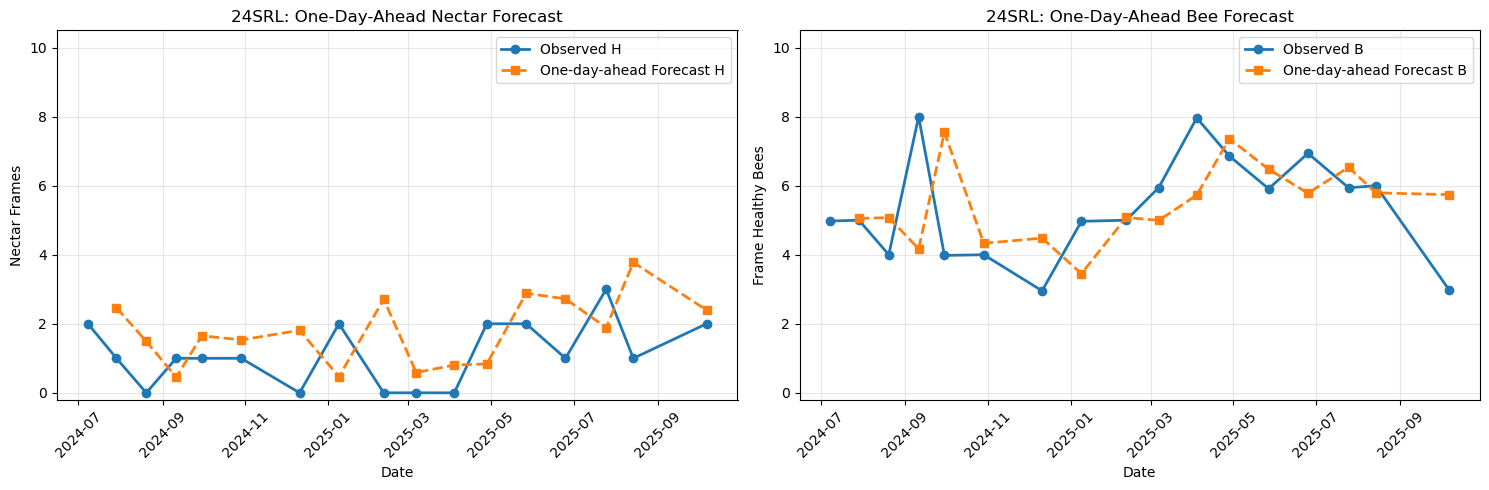

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import glob
import os

# ============================================================
# SETTINGS
# ============================================================

DATA_FOLDER = r"C:\Bee Temp Data\24SR"   # <-- new dataset folder

K = 20

# ============================================================
# FIXED PARAMETERS FROM TRAINING DATA
# Replace these with your estimated values
# ============================================================

params_hat = {
    
    "c1": 0.01661594,
    "c2": 0.01220000,
    "c3": 0.05376478,
    "c7":  0.01,
}

# ============================================================
# LOAD ALL HIVE FILES
# ============================================================

csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.csv")))

print("\nLoaded files:")
for f in csv_files:
    print(os.path.basename(f))

all_hives = []

for file in csv_files:
    data = pd.read_csv(file)
    data["Date"] = pd.to_datetime(data["Date"])

    hive = {
        "name": os.path.basename(file).replace(".csv", ""),
        "data": data,
        "t": np.array(data["Day"], dtype=float),
        "dates": np.array(data["Date"]),
        "obs": {
            "H": np.array(data["Nectar"], dtype=float),
            "B": np.array(data["Frame Healthy Bees"], dtype=float),
        },
    }

    all_hives.append(hive)

# ============================================================
# QUEEN FUNCTION
# ============================================================

def queen_absence_window_func(inspection_times, queen_values, d1=0, d2=2):
    inspection_times = np.asarray(inspection_times, dtype=float)
    queen_values = np.asarray(queen_values, dtype=float)

    windows = []

    for t, q in zip(inspection_times, queen_values):
        if q == 0:
            windows.append((t - d1, t + d2))

    def Q_func(t):
        for start, end in windows:
            if start <= t <= end:
                return 0.0
        return 1.0

    return Q_func

# ============================================================
# ODE MODEL
# ============================================================

def ode_rhs(t, y, p, Q_func):
    H = float(y[0])
    B = float(y[1])

    Q = float(Q_func(t))

    S_collect = 1.0 / (1.0 + np.exp(K * (H - 10.0)))
    S_consume = 1.0 / (1.0 + np.exp(-K * (H - 0.01)))

    dH = (
        B * p["c1"] * S_collect
        - B * p["c2"] * S_consume
    )

    dB = (
        p["c3"] * Q * S_collect * S_consume
        - B * (
            2*p["c7"]
            + (p["c7"] - 2*p["c7"])
            / (1.0 + np.exp(-K * (H - 0.01)))
        )
    )

    return [dH, dB]

# ============================================================
# SOLVER
# ============================================================

def simulate_model(t_points, y0, params, Q_func):
    t_points = np.asarray(t_points, dtype=float)

    if len(t_points) < 2:
        return np.array([[y0[0]], [y0[1]]])

    sol = solve_ivp(
        fun=lambda t, y: ode_rhs(t, y, params, Q_func),
        t_span=(t_points[0], t_points[-1]),
        y0=np.asarray(y0, dtype=float),
        t_eval=t_points,
        method="RK45",
        rtol=1e-4,
        atol=1e-6,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol.y

# ============================================================
# ONE-DAY-AHEAD FORECASTING
# No forecast for first day.
# Day i observation forecasts Day i+1.
# ============================================================

forecast_records = {}

for hive in all_hives:
    name = hive["name"]

    t_all = hive["t"]
    dates = hive["dates"]

    obsH = hive["obs"]["H"]
    obsB = hive["obs"]["B"]

    Q_func = queen_absence_window_func(
        hive["data"]["Day"],
        hive["data"]["Queen"],
    )

    records = []

    for i in range(len(t_all) - 1):

        # Current observed point is used as initial condition
        y0 = [
            obsH[i],
            obsB[i],
        ]

        # Forecast from current day to next day
        t_forecast = np.array([
            t_all[i],
            t_all[i + 1],
        ])

        Y = simulate_model(
            t_forecast,
            y0,
            params_hat,
            Q_func,
        )

        H_forecast = Y[0][-1]
        B_forecast = Y[1][-1]

        records.append({
            "from_index": i,
            "forecast_index": i + 1,

            "from_day": t_all[i],
            "forecast_day": t_all[i + 1],
            "forecast_date": dates[i + 1],

            "H_obs": obsH[i + 1],
            "H_forecast": H_forecast,
            "H_error": H_forecast - obsH[i + 1],

            "B_obs": obsB[i + 1],
            "B_forecast": B_forecast,
            "B_error": B_forecast - obsB[i + 1],
        })

    forecast_records[name] = pd.DataFrame(records)

# ============================================================
# PRINT FORECAST TABLES
# ============================================================

for hive in all_hives:
    name = hive["name"]
    df_forecast = forecast_records[name]

    print("\n" + "=" * 80)
    print(f"ONE-DAY-AHEAD FORECAST RESULTS: {name}")
    print("=" * 80)

    if len(df_forecast) == 0:
        print("No forecast records.")
        continue

    print(df_forecast.round(4).to_string(index=False))

    H_rmse = np.sqrt(np.mean(df_forecast["H_error"] ** 2))
    B_rmse = np.sqrt(np.mean(df_forecast["B_error"] ** 2))

    print("\nForecast RMSE:")
    print(f"H RMSE = {H_rmse:.4f}")
    print(f"B RMSE = {B_rmse:.4f}")

# ============================================================
# PLOTS
# ============================================================

for hive in all_hives:
    name = hive["name"]

    dates = hive["dates"]
    obsH = hive["obs"]["H"]
    obsB = hive["obs"]["B"]

    df_forecast = forecast_records[name]

    if len(df_forecast) == 0:
        continue

    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # --------------------------------------------------------
    # Nectar / Honey
    # --------------------------------------------------------

    axs[0].plot(
        dates,
        obsH,
        "o-",
        label="Observed H",
        linewidth=2,
    )

    axs[0].plot(
        df_forecast["forecast_date"],
        df_forecast["H_forecast"],
        "s--",
        label="One-day-ahead Forecast H",
        linewidth=2,
    )

    axs[0].set_title(f"{name}: One-Day-Ahead Nectar Forecast")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Nectar Frames")
    axs[0].set_ylim(-0.2, 10.5)
    axs[0].grid(alpha=0.3)
    axs[0].legend()
    axs[0].tick_params(axis="x", rotation=45)

    # --------------------------------------------------------
    # Bees
    # --------------------------------------------------------

    axs[1].plot(
        dates,
        obsB,
        "o-",
        label="Observed B",
        linewidth=2,
    )

    axs[1].plot(
        df_forecast["forecast_date"],
        df_forecast["B_forecast"],
        "s--",
        label="One-day-ahead Forecast B",
        linewidth=2,
    )

    axs[1].set_title(f"{name}: One-Day-Ahead Bee Forecast")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Frame Healthy Bees")
    axs[1].set_ylim(-0.2, 10.5)
    axs[1].grid(alpha=0.3)
    axs[1].legend()
    axs[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()